In [25]:
# CELL 1 - Imports, settings, paths
import os
import json
import joblib
from pathlib import Path
import numpy as np
import pandas as pd
from collections import Counter

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn / imblearn
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

# imblearn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# LightGBM
from lightgbm import LGBMClassifier
import lightgbm as lgb

# reproducibility and paths
RND = 42
DATA_PATH = "data_with_burnout.csv"           
MODEL_DIR = "saved_models_binary_high_v2_all" # <<<  set folder to save models/artifacts
os.makedirs(MODEL_DIR, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("MODEL_DIR:", MODEL_DIR)
print("Random seed:", RND)


DATA_PATH: data_with_burnout.csv
MODEL_DIR: saved_models_binary_high_v2_all
Random seed: 42


In [26]:
# CELL 2 - Load dataset and robustly create binary target
df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH, "shape:", df.shape)
display(df.head())

# Ensure burnout label exists
if 'burnout_level' not in df.columns:
    raise KeyError("Column 'burnout_level' not found; update DATA_PATH or column name.")

# Normalize label strings to avoid capitalization issues and create binary target
df['burnout_level_norm'] = df['burnout_level'].astype(str).str.strip().str.lower()

# Map likely variants (extend set if your dataset uses other strings)
high_values = {'high burnout', 'high_burnout', 'high', 'high-burnout'}
df['high_burnout'] = df['burnout_level_norm'].apply(lambda x: 1 if x in high_values else 0)

print("\nValue counts for normalized burnout label:")
print(df['burnout_level_norm'].value_counts(dropna=False).head(20))
print("\nBinary target distribution (high_burnout):")
print(df['high_burnout'].value_counts())


Loaded: data_with_burnout.csv shape: (2601, 26)


,id,nwave,longipart,age,sex,year,bmi,physact,health,psyt,...,educ_par,jobhours,cesd,bdi_su,stai,stress,mbi_ex,mbi_cy,mbi_ea,burnout_level
0,36,1,1,21.0,2,2,24.158817,0.0,2.0,1.0,...,2,0.0,19.0,0.0,48.0,6.0,19.0,11.0,20.0,Moderate Burnout
1,61,1,1,20.0,2,1,27.440599,2.0,3.0,1.0,...,0,4.0,28.0,1.0,51.0,6.0,17.0,14.0,21.0,High Burnout
2,63,1,1,26.0,1,6,23.849777,3.0,4.0,0.0,...,2,10.0,1.0,0.0,23.0,1.0,10.0,11.0,18.0,Moderate Burnout
3,64,1,1,19.0,2,1,21.877550,3.0,3.0,0.0,...,1,0.0,54.0,2.0,72.0,8.0,30.0,23.0,16.0,High Burnout
4,69,1,1,22.0,2,3,20.077335,0.0,4.0,0.0,...,2,0.0,24.0,0.0,55.0,5.0,27.0,14.0,22.0,High Burnout



Value counts for normalized burnout label:
burnout_level_norm
moderate burnout    1525
low burnout          599
high burnout         477
Name: count, dtype: int64

Binary target distribution (high_burnout):
high_burnout
0    2124
1     477
Name: count, dtype: int64


In [27]:
# CELL 3 - quick numeric summary and missing values
print("Dataframe shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)

print("\nMissing values per column (top 50):")
miss = df.isna().sum().sort_values(ascending=False)
print(miss.head(50))

print("\nBasic numeric description:")
display(df.describe(include=[np.number]).T)


Dataframe shape: (2601, 28)

Column dtypes:
id                      int64
nwave                   int64
longipart               int64
age                   float64
sex                     int64
year                    int64
bmi                   float64
physact               float64
health                float64
psyt                  float64
cop_e                 float64
cop_p                 float64
cop_h                 float64
fmale                   int64
part                  float64
socsup                float64
educ_par                int64
jobhours              float64
cesd                  float64
bdi_su                float64
stai                  float64
stress                float64
mbi_ex                float64
mbi_cy                float64
mbi_ea                float64
burnout_level          object
burnout_level_norm     object
high_burnout            int64
dtype: object

Missing values per column (top 50):
socsup                15
cop_h                 15
cop_p          

,count,mean,std,min,25%,50%,75%,max
id,2601.0,2984.692810,1692.245827,2.000000,1515.000000,3016.000000,4451.000000,5836.000000
nwave,2601.0,2.019608,0.847621,1.000000,1.000000,2.000000,3.000000,3.000000
longipart,2601.0,51.133026,55.399771,1.000000,3.000000,23.000000,123.000000,123.000000
age,2594.0,22.276793,3.139467,17.000000,20.000000,22.000000,24.000000,51.000000
sex,2601.0,1.696271,0.478802,1.000000,1.000000,2.000000,2.000000,3.000000
year,2601.0,3.284121,1.726828,1.000000,2.000000,3.000000,5.000000,6.000000
bmi,2595.0,21.739017,2.942610,15.426997,19.723183,21.303949,23.148148,41.665058
physact,2598.0,3.240955,2.651869,0.000000,1.000000,3.000000,5.000000,21.000000
health,2598.0,3.786374,0.979662,1.000000,3.000000,4.000000,4.000000,5.000000
psyt,2598.0,0.239030,0.426573,0.000000,0.000000,0.000000,0.000000,1.000000


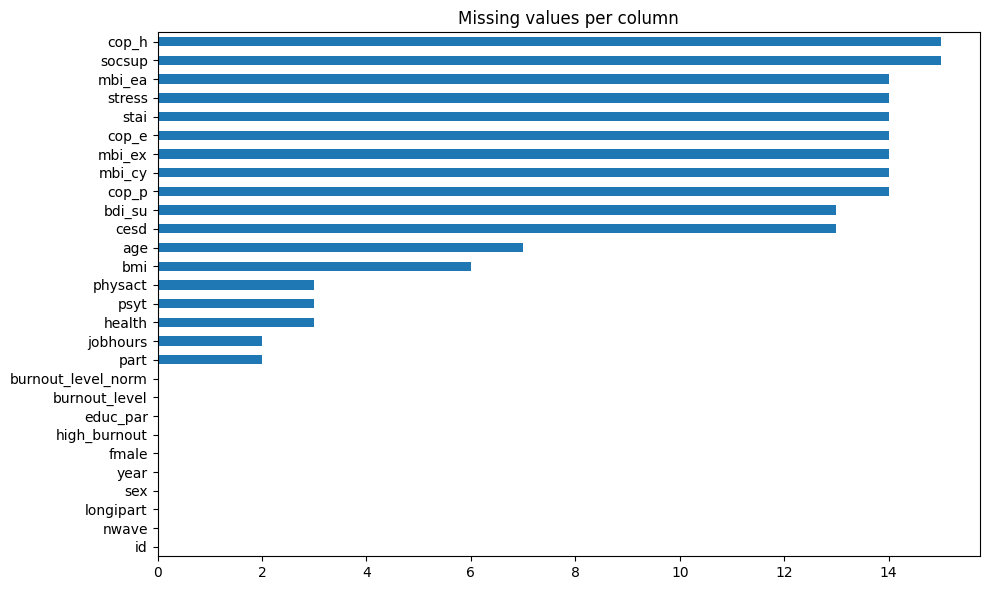

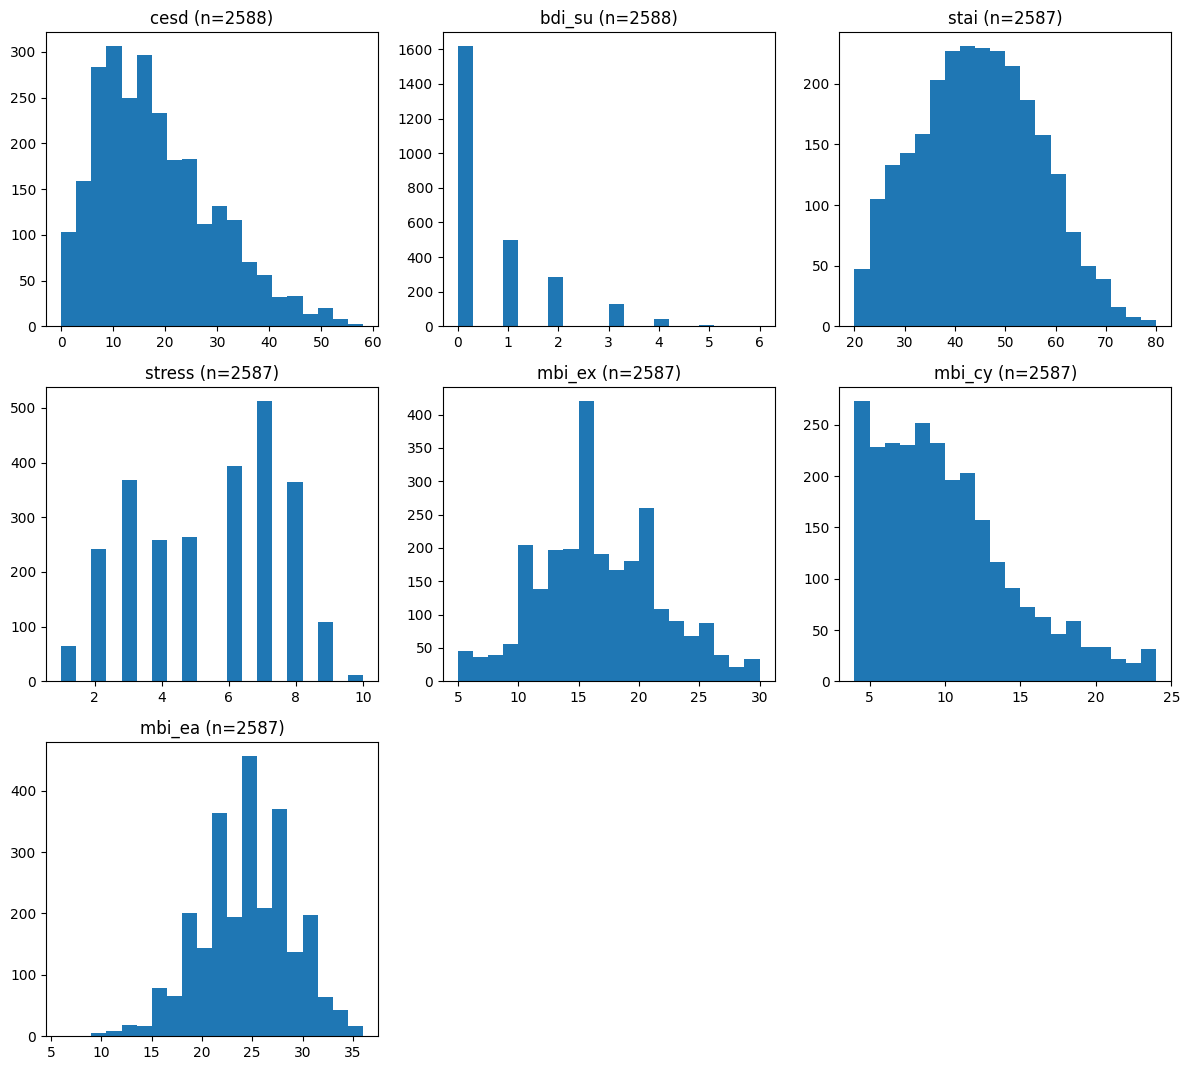

In [28]:
# CELL 4 - EDA plots: missing bar + histograms for psych variables
# adjust psych_cols list as present in your data
psych_cols = ['cesd', 'bdi_su', 'stai', 'stress', 'mbi_ex', 'mbi_cy', 'mbi_ea']
psych_cols = [c for c in psych_cols if c in df.columns]

# Missing values bar chart
plt.figure(figsize=(10,6))
miss = df.isna().sum().sort_values(ascending=True)
miss.plot.barh()
plt.title('Missing values per column')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_missing_values.png"), dpi=150)
plt.show()

# Histograms for psych columns
if psych_cols:
    n = len(psych_cols)
    cols = 3
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols*4, rows*3.6))
    for i, c in enumerate(psych_cols):
        plt.subplot(rows, cols, i+1)
        vals = df[c].dropna()
        plt.hist(vals, bins=20)
        plt.title(f"{c} (n={len(vals)})")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, "eda_psych_histograms.png"), dpi=150)
    plt.show()
else:
    print("No psych columns found for histograms.")


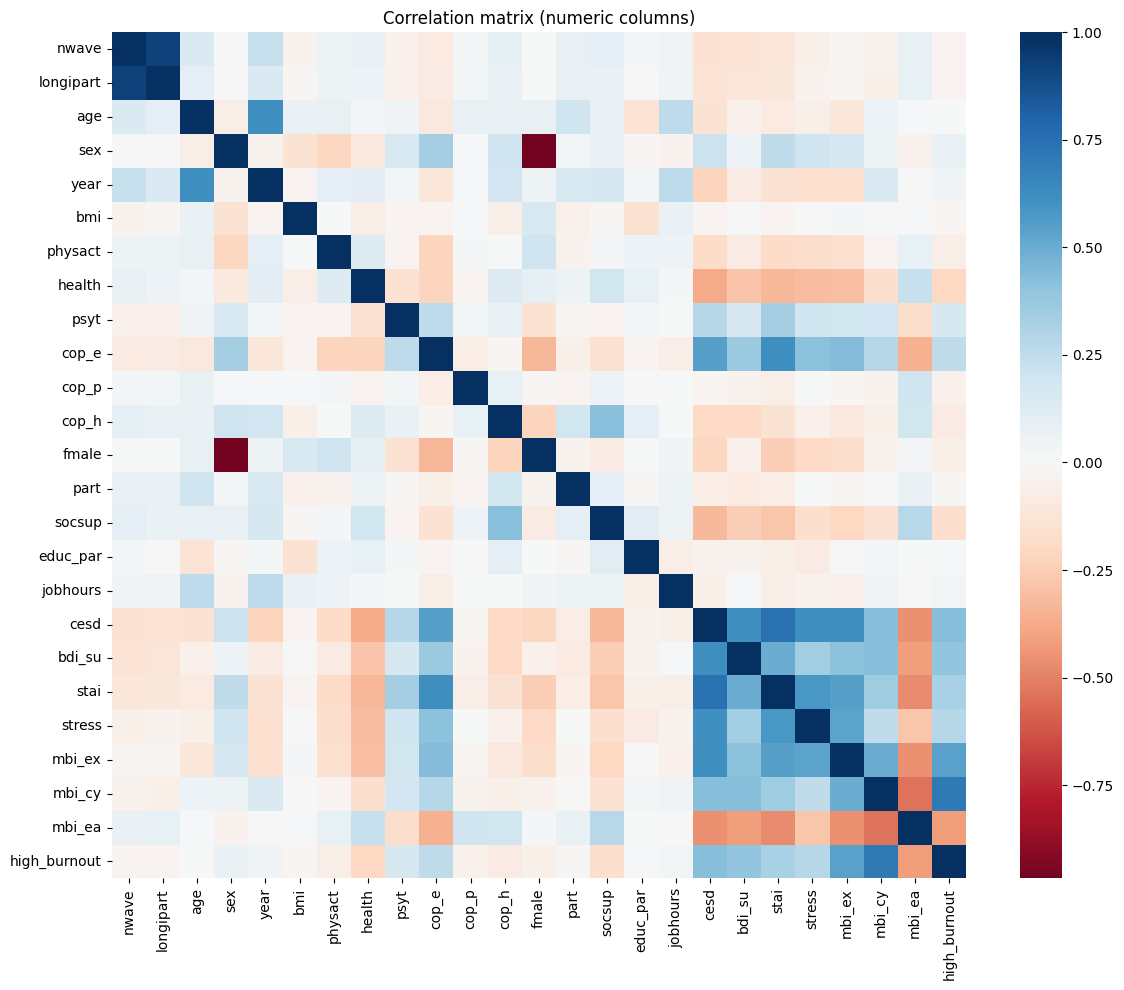

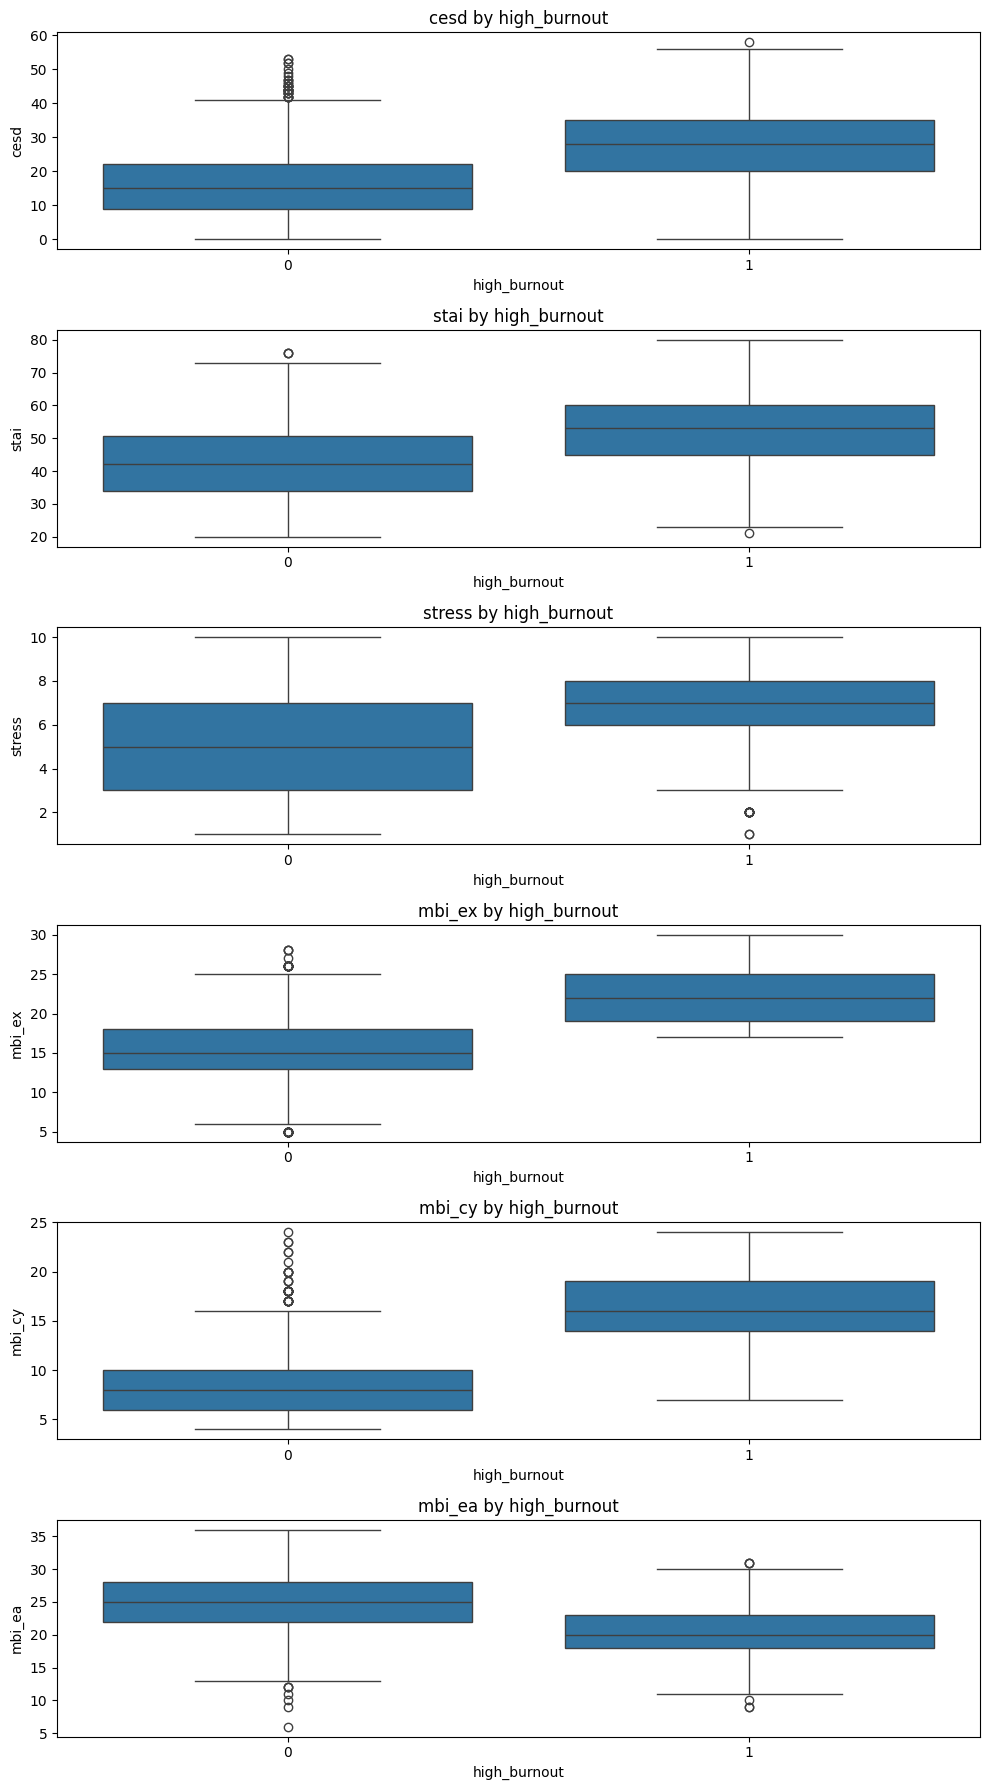

In [29]:
# CELL 5 - Correlation matrix and boxplots by target
import numpy as np

# create binary if not present (safe)
if 'high_burnout' not in df.columns:
    df['high_burnout'] = (df['burnout_level'].astype(str).str.lower() == 'high burnout').astype(int)

num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude id-like if present
for ex in ['id', 'index']:
    if ex in num_cols_all:
        num_cols_all.remove(ex)

corr = df[num_cols_all].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='RdBu', center=0, annot=False)
plt.title("Correlation matrix (numeric columns)")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_corr_matrix.png"), dpi=150)
plt.show()

# Boxplots for key psych features by high_burnout
psych_cols = [c for c in ['cesd','stai','stress','mbi_ex','mbi_cy','mbi_ea'] if c in df.columns]
if psych_cols:
    plt.figure(figsize=(10, 3*len(psych_cols)))
    for i, c in enumerate(psych_cols):
        plt.subplot(len(psych_cols), 1, i+1)
        sns.boxplot(x='high_burnout', y=c, data=df)
        plt.title(f"{c} by high_burnout")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, "eda_boxplots_by_high.png"), dpi=150)
    plt.show()
else:
    print("No psych columns for boxplots.")


In [30]:
df.head(10)

,id,nwave,longipart,age,sex,year,bmi,physact,health,psyt,...,cesd,bdi_su,stai,stress,mbi_ex,mbi_cy,mbi_ea,burnout_level,burnout_level_norm,high_burnout
0,36,1,1,21.0,2,2,24.158817,0.0,2.0,1.0,...,19.0,0.0,48.0,6.0,19.0,11.0,20.0,Moderate Burnout,moderate burnout,0
1,61,1,1,20.0,2,1,27.440599,2.0,3.0,1.0,...,28.0,1.0,51.0,6.0,17.0,14.0,21.0,High Burnout,high burnout,1
2,63,1,1,26.0,1,6,23.849777,3.0,4.0,0.0,...,1.0,0.0,23.0,1.0,10.0,11.0,18.0,Moderate Burnout,moderate burnout,0
3,64,1,1,19.0,2,1,21.877550,3.0,3.0,0.0,...,54.0,2.0,72.0,8.0,30.0,23.0,16.0,High Burnout,high burnout,1
4,69,1,1,22.0,2,3,20.077335,0.0,4.0,0.0,...,24.0,0.0,55.0,5.0,27.0,14.0,22.0,High Burnout,high burnout,1
5,80,1,1,23.0,2,6,17.569651,4.0,2.0,1.0,...,34.0,1.0,64.0,8.0,21.0,12.0,24.0,Moderate Burnout,moderate burnout,0
6,85,1,1,18.0,2,1,18.621386,3.0,4.0,0.0,...,34.0,3.0,59.0,6.0,23.0,21.0,19.0,High Burnout,high burnout,1
7,87,1,1,20.0,2,1,21.303949,1.0,4.0,0.0,...,25.0,0.0,43.0,8.0,17.0,9.0,26.0,Moderate Burnout,moderate burnout,0
8,88,1,1,25.0,2,6,23.011177,0.0,4.0,0.0,...,14.0,0.0,47.0,7.0,12.0,6.0,30.0,Low Burnout,low burnout,0
9,95,1,1,26.0,2,6,19.047005,4.0,4.0,0.0,...,8.0,0.0,39.0,7.0,12.0,11.0,27.0,Moderate Burnout,moderate burnout,0


In [31]:
# CELL 6 - create binary target if not already and drop leakage MBI subscales
df = df.copy()
if 'high_burnout' not in df.columns:
    df['high_burnout'] = (df['burnout_level'].astype(str).str.lower() == 'high burnout').astype(int)

print("Binary target distribution:")
print(df['high_burnout'].value_counts())

# Remove direct leakage columns if present
leak_cols = ['mbi_ex', 'mbi_cy', 'mbi_ea', 'burnout_level', 'burnout_level_norm']
for c in leak_cols:
    if c in df.columns:
        df.drop(columns=c, inplace=True)

print("Dropped leakage columns (if found). Remaining shape:", df.shape)


Binary target distribution:
high_burnout
0    2124
1     477
Name: count, dtype: int64
Dropped leakage columns (if found). Remaining shape: (2601, 23)


In [32]:
# CELL 7 - define feature lists (explicit is recommended)
excluded = {'id', 'high_burnout'}  # extend if you have other id columns
candidate_features = [c for c in df.columns if c not in excluded]

# Auto-detect numeric vs categorical
num_cols = df[candidate_features].select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = [c for c in candidate_features if c not in num_cols]

# Columns that are numeric-coded categories (customize as needed)
for maybe_cat in ['nwave','longipart','year','educ_par','fmale','sex']:
    if maybe_cat in num_cols:
        num_cols.remove(maybe_cat)
        if maybe_cat not in cat_cols:
            cat_cols.append(maybe_cat)

# Drop constant columns (nunique <= 1)
constant_cols = [c for c in candidate_features if df[c].nunique(dropna=True) <= 1]
if constant_cols:
    print("Dropping constant columns:", constant_cols)
    candidate_features = [c for c in candidate_features if c not in constant_cols]
    num_cols = [c for c in num_cols if c not in constant_cols]
    cat_cols = [c for c in cat_cols if c not in constant_cols]

FEATURE_COLUMNS = candidate_features
NUM_COLS = num_cols
CAT_COLS = cat_cols

print("Candidate features (count):", len(FEATURE_COLUMNS))
print("Numeric features:", NUM_COLS)
print("Categorical features:", CAT_COLS)


Candidate features (count): 21
Numeric features: ['age', 'bmi', 'physact', 'health', 'psyt', 'cop_e', 'cop_p', 'cop_h', 'part', 'socsup', 'jobhours', 'cesd', 'bdi_su', 'stai', 'stress']
Categorical features: ['nwave', 'longipart', 'year', 'educ_par', 'fmale', 'sex']


In [33]:
# CELL 8 - Train-test split
X = df[FEATURE_COLUMNS].copy()
y = df['high_burnout'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RND)
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

# Save indices
pd.Series(X_train.index).to_csv(os.path.join(MODEL_DIR, "train_index.csv"), index=False)
pd.Series(X_test.index).to_csv(os.path.join(MODEL_DIR, "test_index.csv"), index=False)


X_train: (2080, 21) X_test: (521, 21)
y_train distribution:
 high_burnout
0    1699
1     381
Name: count, dtype: int64
y_test distribution:
 high_burnout
0    425
1     96
Name: count, dtype: int64


In [34]:
# CELL 9 - Preprocessing pipelines
# OneHotEncoder compatibility
ohe_kwargs = {'handle_unknown': 'ignore'}
try:
    ohe = OneHotEncoder(sparse_output=False, **ohe_kwargs)
except TypeError:
    ohe = OneHotEncoder(sparse=False, **ohe_kwargs)

num_pipeline = SkPipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

cat_pipeline = SkPipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe)
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, NUM_COLS),
    ('cat', cat_pipeline, CAT_COLS)
], remainder='drop')

# Fit preprocessor on training set
preprocessor.fit(X_train)

# Helper to get final feature names robustly
def get_preprocessed_feature_names(ct, input_features):
    try:
        return ct.get_feature_names_out(input_features).tolist()
    except Exception:
        names = []
        for name, trans, cols in ct.transformers_:
            if name == 'remainder':
                continue
            if name == 'num':
                names.extend(cols)
            else:
                try:
                    ohe_local = trans.named_steps['onehot']
                    cats = ohe_local.categories_
                    for col, catvals in zip(cols, cats):
                        names.extend([f"{col}__{v}" for v in catvals])
                except Exception:
                    names.extend(cols)
        return names

final_feature_names = get_preprocessed_feature_names(preprocessor, FEATURE_COLUMNS)
print("Preprocessed feature count:", len(final_feature_names))
print("Preview:", final_feature_names[:20])

# Transform to get numeric matrices (useful for baselines)
X_train_p = preprocessor.transform(X_train)
X_test_p = preprocessor.transform(X_test)
print("Transformed shapes:", X_train_p.shape, X_test_p.shape)


Preprocessed feature count: 39
Preview: ['num__age', 'num__bmi', 'num__physact', 'num__health', 'num__psyt', 'num__cop_e', 'num__cop_p', 'num__cop_h', 'num__part', 'num__socsup', 'num__jobhours', 'num__cesd', 'num__bdi_su', 'num__stai', 'num__stress', 'cat__nwave_1', 'cat__nwave_2', 'cat__nwave_3', 'cat__longipart_1', 'cat__longipart_2']
Transformed shapes: (2080, 39) (521, 39)


In [35]:
# CELL 10 - quick baseline CV to get a sense of models
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

baselines = {
    'logreg': LGBMClassifier(n_estimators=200, random_state=RND, n_jobs=-1),  # quick LGBM baseline
}

for name, clf in baselines.items():
    scores = cross_val_score(clf, X_train_p, y_train, cv=skf, scoring='f1', n_jobs=-1)
    print(f"{name}: mean CV F1 = {scores.mean():.4f} (std {scores.std():.4f})")


logreg: mean CV F1 = 0.4553 (std 0.0699)


In [36]:
# CELL 11 - pipeline builder for search (SMOTE inside if selected)
USE_SMOTE = True  # <<< CHANGE: True -> use SMOTE for resampling during CV; False -> use weight-based balancing

def make_search_pipeline(clf, use_smote=USE_SMOTE):
    if use_smote:
        pip = ImbPipeline([
            ('pre', preprocessor),
            ('smote', SMOTE(random_state=RND)),
            ('clf', clf)
        ])
    else:
        pip = SkPipeline([
            ('pre', preprocessor),
            ('clf', clf)
        ])
    return pip

# Example pipeline print
print(make_search_pipeline(LGBMClassifier(random_state=RND, n_jobs=-1)))


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'physact',
                                                   'health', 'psyt', 'cop_e',
                                                   'cop_p', 'cop_h', 'part',
                                                   'socsup', 'jobhours', 'cesd',
                                                   'bdi_su', 'stai',
                                                   'stress']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute'

In [37]:
# CELL 12 - RandomizedSearchCV for LightGBM (tune hyperparams)
param_dist_lgb = {
    'clf__n_estimators': [100, 200, 400],
    'clf__learning_rate': [0.01, 0.02, 0.05],
    'clf__num_leaves': [15, 31, 63],
    'clf__max_depth': [4, 6, 8, -1],
    'clf__subsample': [0.6, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
    'clf__min_child_samples': [10, 20, 50]
}

base_clf = LGBMClassifier(objective='binary', random_state=RND, n_jobs=-1, verbosity=-1)
search_pipe = make_search_pipeline(base_clf, use_smote=USE_SMOTE)

n_iter_search = 30   # <<< CHANGE: increase if you have more time/resources
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RND)

rnd = RandomizedSearchCV(
    estimator=search_pipe,
    param_distributions=param_dist_lgb,
    n_iter=n_iter_search,
    scoring='f1',
    cv=cv,
    random_state=RND,
    n_jobs=-1,
    verbose=2
)

print("Starting RandomizedSearchCV (this can be time-consuming)...")
rnd.fit(X_train, y_train)  # pass raw X; pipeline inside handles preprocessing & SMOTE
print("Best CV F1:", rnd.best_score_)
print("Best params:", rnd.best_params_)

# Save search results & best estimator
joblib.dump(rnd, os.path.join(MODEL_DIR, "rnd_search_lgbm.pkl"))
joblib.dump(rnd.best_estimator_, os.path.join(MODEL_DIR, "best_search_pipeline_lgbm.pkl"))
print("Saved randomized search and best search pipeline.")


Starting RandomizedSearchCV (this can be time-consuming)...
Fitting 4 folds for each of 30 candidates, totalling 120 fits
Best CV F1: 0.533041844661563
Best params: {'clf__subsample': 0.6, 'clf__num_leaves': 63, 'clf__n_estimators': 200, 'clf__min_child_samples': 50, 'clf__max_depth': 4, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.8}
Saved randomized search and best search pipeline.


In [38]:
# CELL 13 - Final model training with early stopping (and saving final pipeline without SMOTE)
best_search_path = os.path.join(MODEL_DIR, "best_search_pipeline_lgbm.pkl")
if not os.path.exists(best_search_path):
    # fallback: use rnd.best_estimator_ if rnd exists
    try:
        best_search_pipe = rnd.best_estimator_
    except NameError:
        raise FileNotFoundError("Best search pipeline not found. Run tuning cell first.")
else:
    best_search_pipe = joblib.load(best_search_path)

# Extract preprocessor and classifier
if hasattr(best_search_pipe, 'named_steps') and 'pre' in best_search_pipe.named_steps:
    fitted_preprocessor = best_search_pipe.named_steps['pre']
else:
    fitted_preprocessor = preprocessor  # fallback

if hasattr(best_search_pipe, 'named_steps') and 'clf' in best_search_pipe.named_steps:
    clf_est = best_search_pipe.named_steps['clf']
else:
    clf_est = best_search_pipe

print("Classifier type:", type(clf_est))

# Create a small hold-out val split from X_train for early stopping and threshold tuning
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, stratify=y_train, random_state=RND)
print("X_tr:", X_tr.shape, "X_val:", X_val.shape)

# Transform using fitted_preprocessor
X_tr_p = fitted_preprocessor.transform(X_tr)
X_val_p = fitted_preprocessor.transform(X_val)
print("Preprocessed shapes:", X_tr_p.shape, X_val_p.shape)

# Optionally apply SMOTE to training matrix only
if USE_SMOTE:
    sm = SMOTE(random_state=RND)
    X_tr_res, y_tr_res = sm.fit_resample(X_tr_p, y_tr)
    print("After SMOTE training distribution:", Counter(y_tr_res))
else:
    X_tr_res, y_tr_res = X_tr_p, y_tr

# Fit LGBM directly (so evals_result_ and early stopping work)
if isinstance(clf_est, LGBMClassifier):
    clf_est.set_params(n_jobs=-1, verbosity=-1)
    clf_est.fit(
        X_tr_res, y_tr_res,
        eval_set=[(X_val_p, y_val)],
        eval_metric='binary_logloss',
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(0)]
    )
else:
    clf_est.fit(X_tr_res, y_tr_res)

# Final inference pipeline: preprocessor + trained classifier (NO SMOTE)
final_pipeline = SkPipeline([('pre', fitted_preprocessor), ('clf', clf_est)])
final_path = os.path.join(MODEL_DIR, "final_pipeline_lgbm.pkl")
joblib.dump(final_pipeline, final_path)
print("Saved final pipeline to:", final_path)

# Save evals_result if present and preprocessed debug arrays
try:
    joblib.dump({'X_val_p': X_val_p, 'y_val': y_val, 'X_tr_p': X_tr_p, 'y_tr': y_tr}, os.path.join(MODEL_DIR, 'preprocessed_debug_arrays.pkl'))
    if hasattr(clf_est, 'evals_result_'):
        joblib.dump(clf_est.evals_result_, os.path.join(MODEL_DIR, 'lgbm_evals_result.pkl'))
        print("Saved evals_result_.")
except Exception as e:
    print("Warning saving debug arrays/evals_result:", e)


Classifier type: <class 'lightgbm.sklearn.LGBMClassifier'>
X_tr: (1768, 21) X_val: (312, 21)
Preprocessed shapes: (1768, 39) (312, 39)
After SMOTE training distribution: Counter({0: 1444, 1: 1444})
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[200]	valid_0's binary_logloss: 0.420825
Saved final pipeline to: saved_models_binary_high_v2_all\final_pipeline_lgbm.pkl
Saved evals_result_.


In [39]:
# CELL 14 - Threshold tuning using X_val and evaluation on X_test
final_pipe = joblib.load(final_path)

# Use X_val/y_val from previous cell; if not available, re-create same split
# Compute probabilities
y_val_proba = final_pipe.predict_proba(X_val)[:, 1]
y_test_proba = final_pipe.predict_proba(X_test)[:, 1]

# Find threshold maximizing F1 on validation
thresholds = np.linspace(0.01, 0.99, 99)
best = (0.5, f1_score(y_val, (y_val_proba >= 0.5).astype(int)))
for t in thresholds:
    f = f1_score(y_val, (y_val_proba >= t).astype(int))
    if f > best[1]:
        best = (t, f)
chosen_threshold = float(best[0])
print("Best threshold by F1 (validation):", chosen_threshold, best[1])

# Evaluate on test
y_test_pred = (y_test_proba >= chosen_threshold).astype(int)
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
f1v = f1_score(y_test, y_test_pred, zero_division=0)
roc = roc_auc_score(y_test, y_test_proba)
cm = confusion_matrix(y_test, y_test_pred)

print(f"Test results at threshold {chosen_threshold:.3f}:")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1v)
print("ROC AUC:", roc)
print("Confusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_test, y_test_pred, zero_division=0))

# Save threshold and pipeline
joblib.dump(final_pipeline, os.path.join(MODEL_DIR, "pipeline_with_preproc.pkl"))
joblib.dump(chosen_threshold, os.path.join(MODEL_DIR, "decision_threshold.pkl"))
print("Saved pipeline_with_preproc.pkl and decision_threshold.pkl")


Best threshold by F1 (validation): 0.55 0.6333333333333333
Test results at threshold 0.550:
Accuracy: 0.8138195777351248
Precision: 0.4935064935064935
Recall: 0.3958333333333333
F1: 0.4393063583815029
ROC AUC: 0.8019117647058823
Confusion matrix:
 [[386  39]
 [ 58  38]]

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89       425
           1       0.49      0.40      0.44        96

    accuracy                           0.81       521
   macro avg       0.68      0.65      0.66       521
weighted avg       0.80      0.81      0.81       521

Saved pipeline_with_preproc.pkl and decision_threshold.pkl


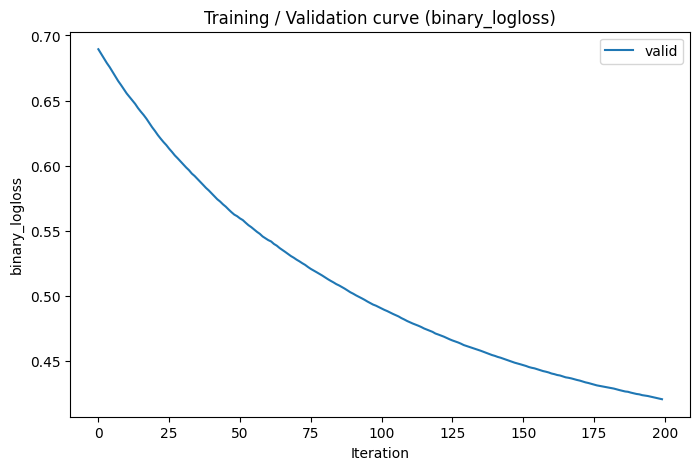

Saved training/validation curve to: saved_models_binary_high_v2_all\train_val_curve.png


In [40]:
# CELL 15 - Plot training/validation curves if evals_result_ was saved
evals_path = os.path.join(MODEL_DIR, 'lgbm_evals_result.pkl')
if os.path.exists(evals_path):
    ev = joblib.load(evals_path)
    # LightGBM structure: ev.get('valid_0')['binary_logloss'] and ev.get('training')['binary_logloss']
    valid = ev.get('valid_0', {}).get('binary_logloss', None) or ev.get('valid_1', {}).get('binary_logloss', None)
    trainv = ev.get('training', {}).get('binary_logloss', None) or ev.get('train', {}).get('binary_logloss', None)
    plt.figure(figsize=(8,5))
    if trainv is not None:
        plt.plot(trainv, label='train')
    if valid is not None:
        plt.plot(valid, label='valid')
    plt.xlabel("Iteration")
    plt.ylabel("binary_logloss")
    plt.legend()
    plt.title("Training / Validation curve (binary_logloss)")
    fout = os.path.join(MODEL_DIR, "train_val_curve.png")
    plt.savefig(fout, dpi=150)
    plt.show()
    print("Saved training/validation curve to:", fout)
else:
    print("No evals_result found at:", evals_path)


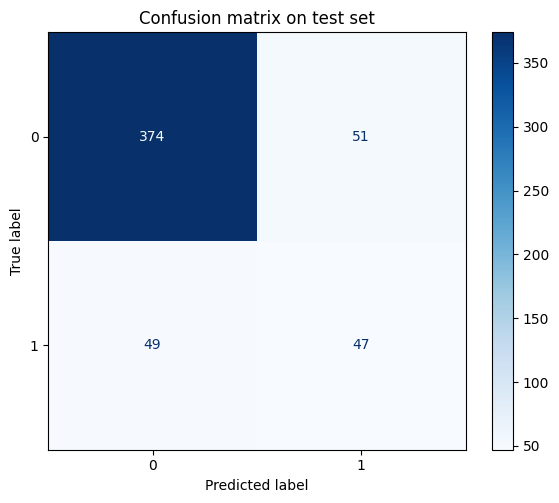

Saved confusion matrix to: saved_models_binary_high_v2_all\confusion_matrix_test.png
Saved predictions to: saved_models_binary_high_v2_all\test_predictions_with_probs.csv


In [41]:
# CELL 16 - Confusion matrix plot and save test predictions
from sklearn.metrics import ConfusionMatrixDisplay

pipe = joblib.load(os.path.join(MODEL_DIR, "pipeline_with_preproc.pkl"))
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:,1] if hasattr(pipe, 'predict_proba') else None

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion matrix on test set")
plt.tight_layout()
fout = os.path.join(MODEL_DIR, "confusion_matrix_test.png")
plt.savefig(fout, dpi=150)
plt.show()
print("Saved confusion matrix to:", fout)

# Save predictions with probabilities
pred_df = X_test.reset_index(drop=True).copy()
pred_df['y_true'] = y_test.reset_index(drop=True)
pred_df['y_pred'] = y_pred
if y_proba is not None:
    pred_df['y_proba'] = y_proba
pred_csv = os.path.join(MODEL_DIR, "test_predictions_with_probs.csv")
pred_df.to_csv(pred_csv, index=False)
print("Saved predictions to:", pred_csv)


Saved feature importances CSV.


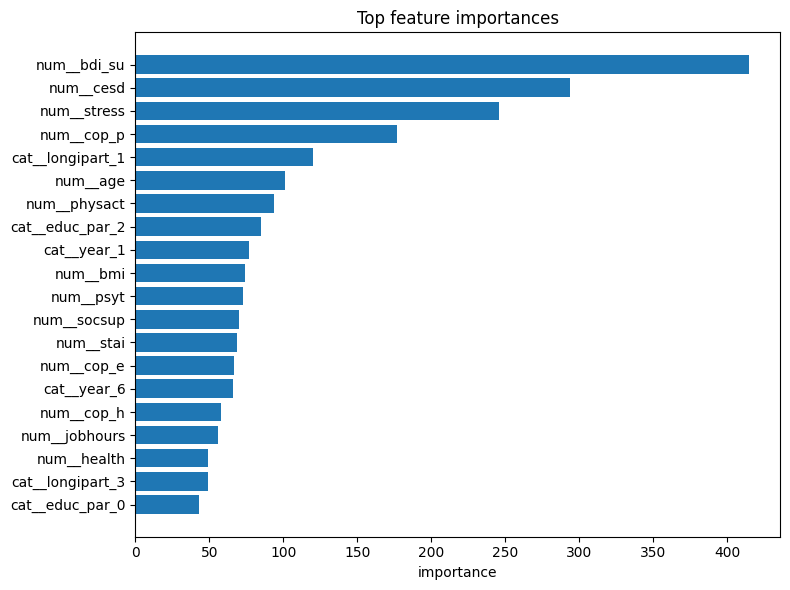

In [42]:
# CELL 17 - Feature importances for LGBM
pipe = joblib.load(os.path.join(MODEL_DIR, "pipeline_with_preproc.pkl"))
clf = pipe.named_steps['clf']
pre = pipe.named_steps['pre']

# get feature names robustly
try:
    feat_names = pre.get_feature_names_out(FEATURE_COLUMNS)
except Exception:
    feat_names = final_feature_names

if hasattr(clf, "feature_importances_"):
    feat_imp = clf.feature_importances_
    if len(feat_imp) == len(feat_names):
        imp_df = pd.DataFrame({'feature': feat_names, 'importance': feat_imp}).sort_values('importance', ascending=False)
    else:
        imp_df = pd.DataFrame({'feature': [f"f{i}" for i in range(len(feat_imp))], 'importance': feat_imp}).sort_values('importance', ascending=False)
    imp_df.to_csv(os.path.join(MODEL_DIR, "feature_importances.csv"), index=False)
    print("Saved feature importances CSV.")
    # Plot top 20
    topk = imp_df.head(20)
    plt.figure(figsize=(8, max(4, len(topk)*0.3)))
    plt.barh(topk['feature'][::-1], topk['importance'][::-1])
    plt.xlabel("importance")
    plt.title("Top feature importances")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, "feature_importances.png"), dpi=150)
    plt.show()
else:
    print("Classifier does not expose feature_importances_.")


In [43]:
# CELL 18 - Save preprocessor, metadata, indices already saved earlier
joblib.dump(preprocessor, os.path.join(MODEL_DIR, "preprocessor.pkl"))
joblib.dump(pipe, os.path.join(MODEL_DIR, "pipeline_with_preproc.pkl"))  # already saved earlier too
joblib.dump(chosen_threshold, os.path.join(MODEL_DIR, "decision_threshold.pkl"))

meta = {
    'data_path': DATA_PATH,
    'feature_columns': FEATURE_COLUMNS,
    'num_cols': NUM_COLS,
    'cat_cols': CAT_COLS,
    'constant_cols_dropped': constant_cols,
    'leakage_columns_removed': leak_cols,
    'random_seed': RND,
    'use_smote': USE_SMOTE,
    'chosen_threshold': float(chosen_threshold)
}
with open(os.path.join(MODEL_DIR, "metadata.json"), "w") as f:
    json.dump(meta, f, indent=2)
print("Saved artifacts and metadata to:", MODEL_DIR)


Saved artifacts and metadata to: saved_models_binary_high_v2_all


In [44]:
# CELL 19 - Example inference: load pipeline & threshold and predict on a raw input (DataFrame)
from pprint import pprint

model = joblib.load(os.path.join(MODEL_DIR, "pipeline_with_preproc.pkl"))
threshold = joblib.load(os.path.join(MODEL_DIR, "decision_threshold.pkl"))

# Use an existing test row as example or craft a dict ensuring FEATURE_COLUMNS keys present
example_row = X_test.iloc[[0]].copy()
print("Raw example input:")
display(example_row)

proba = model.predict_proba(example_row)[:, 1][0]
pred_label = int(proba >= threshold)
print(f"Predicted probability (high_burnout): {proba:.4f}")
print("Predicted class (high_burnout):", pred_label)


Raw example input:


,nwave,longipart,age,sex,year,bmi,physact,health,psyt,cop_e,...,cop_h,fmale,part,socsup,educ_par,jobhours,cesd,bdi_su,stai,stress
874,3,123,25.0,2,5,17.361111,10.0,4.0,0.0,3.0,...,9.0,0,1.0,10.0,2,0.0,5.0,0.0,32.0,8.0


Predicted probability (high_burnout): 0.2025
Predicted class (high_burnout): 0


In [45]:
# Select 5 test rows and show actual class name + predicted class name (with prob)
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --------- SETTINGS (edit if you used different names) ----------
MODEL_DIR = "saved_models_binary_high_v2_all"   # <<< UPDATE if your model dir differs
FINAL_PIPELINE_PATHS = [
    os.path.join(MODEL_DIR, "calibrated_pipeline.pkl"),
    os.path.join(MODEL_DIR, "pipeline_with_preproc.pkl"),
    os.path.join(MODEL_DIR, "final_pipeline_lgbm.pkl")
]  # will try in order: calibrated -> non-calibrated -> final
THRESHOLD_PATH = os.path.join(MODEL_DIR, "decision_threshold.pkl")
TEST_INDEX_PATH = os.path.join(MODEL_DIR, "test_index.csv")
DATA_PATH = "data_with_burnout.csv"  # <<< CHANGE if needed
N_SAMPLES = 5
# ----------------------------------------------------------------

# Load pipeline (prefer calibrated if present)
pipeline = None
for p in FINAL_PIPELINE_PATHS:
    if os.path.exists(p):
        pipeline = joblib.load(p)
        print("Loaded pipeline from:", p)
        break
if pipeline is None:
    raise FileNotFoundError(f"Could not find any pipeline at: {FINAL_PIPELINE_PATHS}")

# Load threshold if available
if os.path.exists(THRESHOLD_PATH):
    try:
        chosen_threshold = float(joblib.load(THRESHOLD_PATH))
        print("Loaded chosen threshold:", chosen_threshold)
    except Exception:
        chosen_threshold = 0.5
        print("Failed to load threshold; using default 0.5")
else:
    chosen_threshold = 0.5
    print("No saved threshold found; using default 0.5")

# Try to use X_test/y_test from the environment; otherwise reconstruct from saved indices
try:
    X_test  # check if exists
    y_test
    print("Using X_test / y_test from current environment.")
except NameError:
    # Reconstruct using saved test indices and data file
    if not os.path.exists(TEST_INDEX_PATH):
        # Fallback: re-split from raw data (must match the split used earlier)
        print("test_index.csv not found. Re-splitting data from scratch (may not match original).")
        df = pd.read_csv(DATA_PATH)
        # create binary target robustly if needed
        if 'high_burnout' not in df.columns:
            if 'burnout_level' in df.columns:
                df['burnout_level_norm'] = df['burnout_level'].astype(str).str.strip().str.lower()
                high_values = {'high burnout', 'high_burnout', 'high', 'high-burnout'}
                df['high_burnout'] = df['burnout_level_norm'].apply(lambda x: 1 if x in high_values else 0)
            else:
                raise KeyError("No 'high_burnout' nor 'burnout_level' column found in data to reconstruct target.")
        feature_cols = [c for c in df.columns if c not in ('id','burnout_level','burnout_level_norm','high_burnout','mbi_ex','mbi_cy','mbi_ea')]
        X = df[feature_cols]
        y = df['high_burnout']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
    else:
        print("Reconstructing test set from saved test_index.csv and data file.")
        df = pd.read_csv(DATA_PATH)
        # Ensure target exists
        if 'high_burnout' not in df.columns:
            if 'burnout_level' in df.columns:
                df['burnout_level_norm'] = df['burnout_level'].astype(str).str.strip().str.lower()
                high_values = {'high burnout', 'high_burnout', 'high', 'high-burnout'}
                df['high_burnout'] = df['burnout_level_norm'].apply(lambda x: 1 if x in high_values else 0)
            else:
                raise KeyError("No 'high_burnout' nor 'burnout_level' column found in data to reconstruct target.")
        # features auto-detect (same logic used in pipeline creation)
        excluded = {'id','burnout_level','burnout_level_norm','high_burnout','mbi_ex','mbi_cy','mbi_ea'}
        feature_cols = [c for c in df.columns if c not in excluded]
        test_idx = pd.read_csv(TEST_INDEX_PATH, squeeze=True).astype(int).tolist()
        X_test = df.loc[test_idx, feature_cols].reset_index(drop=True)
        y_test = df.loc[test_idx, 'high_burnout'].reset_index(drop=True)

# At this point X_test and y_test should exist as DataFrames/Series
# Select 5 rows: aim for 2 true positives, 2 true negatives, and 1 high-probability misclassified if available
# First compute probabilities/predictions for full X_test
if hasattr(pipeline, "predict_proba"):
    proba_all = pipeline.predict_proba(X_test)[:, 1]
else:
    # If predict_proba not available, use predict and set proba to 0/1
    preds_all = pipeline.predict(X_test)
    proba_all = np.array(preds_all, dtype=float)

preds_all = (proba_all >= chosen_threshold).astype(int)

res = X_test.reset_index(drop=True).copy()
res['y_true'] = y_test.reset_index(drop=True)
res['y_proba'] = proba_all
res['y_pred'] = preds_all

# Helper to map class number -> class name
class_name_map = {1: "High Burnout", 0: "Not High Burnout"}
res['y_true_name'] = res['y_true'].map(class_name_map)
res['y_pred_name'] = res['y_pred'].map(class_name_map)

# Build selection: up to 2 true positives, up to 2 true negatives, and 1 misclassified with high prob if exists
tp = res[(res['y_true']==1) & (res['y_pred']==1)].sort_values('y_proba', ascending=False).head(2)
tn = res[(res['y_true']==0) & (res['y_pred']==0)].sort_values('y_proba', ascending=True).head(2)
# misclassified with highest prob where pred==1 but true==0 or pred==0 but true==1
mis_high = res[(res['y_true'] != res['y_pred'])].sort_values('y_proba', ascending=False).head(1)

# Combine unique rows
sample5 = pd.concat([tp, tn, mis_high]).drop_duplicates().reset_index(drop=True)
# If not enough rows, pad with highest probability examples
if len(sample5) < N_SAMPLES:
    remaining = res.drop(sample5.index).sort_values('y_proba', ascending=False)
    sample5 = pd.concat([sample5, remaining.head(N_SAMPLES - len(sample5))]).reset_index(drop=True)

# Select columns to show (features + meta)
cols_to_show = list(X_test.columns[:20])  # show up to first 20 original features for readability
# ensure we include key columns even if >20 features exist
meta_cols = ['y_true', 'y_true_name', 'y_proba', 'y_pred', 'y_pred_name']
# final display dataframe
display_cols = [c for c in cols_to_show if c in sample5.columns] + meta_cols
out = sample5[display_cols].copy()

# Print and save
from IPython.display import display
print(f"Selected {len(out)} sample rows from test set (saved to {os.path.join(MODEL_DIR, 'test_sample5_actual_vs_predicted.csv')})")
display(out)
out.to_csv(os.path.join(MODEL_DIR, "test_sample5_actual_vs_predicted.csv"), index=False)


Loaded pipeline from: saved_models_binary_high_v2_all\pipeline_with_preproc.pkl
Loaded chosen threshold: 0.55
Using X_test / y_test from current environment.
Selected 5 sample rows from test set (saved to saved_models_binary_high_v2_all\test_sample5_actual_vs_predicted.csv)


,nwave,longipart,age,sex,year,bmi,physact,health,psyt,cop_e,...,educ_par,jobhours,cesd,bdi_su,stai,y_true,y_true_name,y_proba,y_pred,y_pred_name
0,2,23,21.0,2,2,20.202021,2.0,2.0,0.0,18.0,...,1,3.0,38.0,3.0,55.0,1,High Burnout,0.783996,1,High Burnout
1,2,12,22.0,1,6,22.160666,1.0,4.0,0.0,15.0,...,2,0.0,35.0,2.0,41.0,1,High Burnout,0.782346,1,High Burnout
2,3,123,20.0,1,3,23.124060,3.0,5.0,0.0,5.0,...,2,0.0,3.0,0.0,22.0,0,Not High Burnout,0.082947,0,Not High Burnout
3,2,23,18.0,1,1,22.498175,5.0,4.0,0.0,6.0,...,2,0.0,2.0,0.0,28.0,0,Not High Burnout,0.083962,0,Not High Burnout
4,3,123,22.0,2,2,20.820940,1.0,4.0,0.0,12.0,...,2,0.0,30.0,2.0,61.0,0,Not High Burnout,0.784644,1,High Burnout


In [46]:
# Inspect misclassified sample: locate raw row, SHAP explanation, and nearest neighbors
import os, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

MODEL_DIR = "saved_models_binary_high_v2_all"   # <<< change if different
DATA_PATH = "data_with_burnout.csv"             # <<< change if different
SAMPLE_CSV = os.path.join(MODEL_DIR, "test_sample5_actual_vs_predicted.csv")
FINAL_PIPELINE_PREFS = [
    os.path.join(MODEL_DIR, "calibrated_pipeline.pkl"),
    os.path.join(MODEL_DIR, "pipeline_with_preproc.pkl"),
    os.path.join(MODEL_DIR, "final_pipeline_lgbm.pkl")
]
FINAL_PIPELINE_PATH = None
for p in FINAL_PIPELINE_PREFS:
    if os.path.exists(p):
        FINAL_PIPELINE_PATH = p
        break
if FINAL_PIPELINE_PATH is None:
    raise FileNotFoundError("No pipeline found in MODEL_DIR. Run training and saving steps first.")

print("Using pipeline:", FINAL_PIPELINE_PATH)
pipeline = joblib.load(FINAL_PIPELINE_PATH)

# Load sample CSV
if not os.path.exists(SAMPLE_CSV):
    raise FileNotFoundError(f"Sample CSV not found at {SAMPLE_CSV}. Re-run the sample generation cell first.")
sample_df = pd.read_csv(SAMPLE_CSV)
display(sample_df)

# Choose the misclassified row(s) to inspect: pick rows where y_true != y_pred
mis = sample_df[sample_df['y_true'] != sample_df['y_pred']]
if mis.empty:
    print("No misclassification found in sample file. Pick a row manually from sample_df or recompute a sample with misclassified examples.")
    # optionally let user pick an index
    idx_to_inspect = 0
    sample_row = sample_df.iloc[[idx_to_inspect]]
else:
    # pick the first misclassified row for inspection (you can modify to loop)
    sample_row = mis.iloc[[0]]
    print("Inspecting misclassified sample (first):")
display(sample_row)

# Try to locate this sample's original raw row(s) in the full dataset
raw_df = pd.read_csv(DATA_PATH)
# Build a list of candidate matching columns — adjust if needed
match_cols = [c for c in ['id','nwave','longipart','age','sex','year','bmi','physact','health','cesd','stai'] if c in sample_row.columns and c in raw_df.columns]
print("Attempting to match on columns:", match_cols)

# Try exact match on available match_cols
query_mask = None
for c in match_cols:
    val = sample_row.iloc[0].get(c)
    if pd.isna(val):
        # skip NA matches
        continue
    if query_mask is None:
        query_mask = (raw_df[c] == val)
    else:
        query_mask &= (raw_df[c] == val)

if query_mask is None:
    print("No suitable match columns found; showing top raw rows that are similar by longipart+nwave if available.")
    if 'longipart' in raw_df.columns and 'nwave' in raw_df.columns:
        candidates = raw_df[(raw_df['longipart'] == sample_row.iloc[0]['longipart']) & (raw_df['nwave'] == sample_row.iloc[0]['nwave'])]
        print("Candidates by longipart+nwave:")
        display(candidates.head(10))
    else:
        print("No easy fallback match. You can re-run sample creation storing 'id' or dataframe index.")
else:
    matched = raw_df[query_mask]
    if matched.empty:
        # try looser numeric tolerance matching for floats (age, bmi)
        print("Exact match found 0 rows. Trying loose numeric tolerance matching for numeric columns.")
        loose_mask = None
        for c in match_cols:
            val = sample_row.iloc[0].get(c)
            if pd.isna(val):
                continue
            if raw_df[c].dtype.kind in 'f':  # float
                m = raw_df[c].between(val - 1e-6, val + 1e-6)
            else:
                m = (raw_df[c] == val)
            loose_mask = m if loose_mask is None else (loose_mask & m)
        matched = raw_df[loose_mask] if loose_mask is not None else raw_df.iloc[0:0]

    if matched.empty:
        print("No matching raw row found by exact or loose numeric match. Showing top 10 rows for manual inspection.")
        display(raw_df.head(10))
    else:
        print("Found matched raw row(s) (showing up to 10):")
        display(matched.head(10))
        # If id exists, show it
        if 'id' in matched.columns:
            print("Matched id(s):", matched['id'].tolist())

# --- SHAP explanation ---
# We want the underlying LGBM model (not a calibrated wrapper) for TreeExplainer.
# If pipeline wraps a CalibratedClassifierCV, extract its base_estimator.
clf_wrapper = pipeline.named_steps.get('clf', pipeline)
pre = pipeline.named_steps.get('pre', None)

# extract underlying LGBM if wrapped
lgbm_clf = None
try:
    # CalibratedClassifierCV has attribute base_estimator in older/sklearn variations or estimator_ in some cases
    from sklearn.calibration import CalibratedClassifierCV
    if isinstance(clf_wrapper, CalibratedClassifierCV):
        # attempt to get base estimator
        if hasattr(clf_wrapper, "base_estimator"):
            lgbm_clf = clf_wrapper.base_estimator
        elif hasattr(clf_wrapper, "estimator"):
            lgbm_clf = clf_wrapper.estimator
        elif hasattr(clf_wrapper, "calibrated_classifiers_") and len(clf_wrapper.calibrated_classifiers_)>0:
            # calibrated_classifiers_ wraps fitted clones; try to find underlying
            lgbm_clf = clf_wrapper.calibrated_classifiers_[0].base_estimator if hasattr(clf_wrapper.calibrated_classifiers_[0], 'base_estimator') else None
    else:
        # not a calibrator; assume direct LGBMClassifier or compatible
        lgbm_clf = clf_wrapper
except Exception:
    lgbm_clf = clf_wrapper

if lgbm_clf is None:
    print("Could not extract an underlying LGBM classifier for SHAP. Attempting to use wrapper directly.")
    lgbm_clf = clf_wrapper

print("Using classifier type for SHAP:", type(lgbm_clf))

# Preprocess the sample_row raw features into the model input
# If sample_row contains original features (not preprocessed), use pre.transform
if pre is None:
    raise RuntimeError("Preprocessor step 'pre' not found inside the pipeline. Cannot preprocess sample for SHAP/NN.")

# Build a 1-row DataFrame for the sample using feature columns present in the pipeline preprocessor
# We try to pick the original feature columns used by the pipeline: pre.feature_names_in_ if available
try:
    # sklearn ColumnTransformer exposes feature_names_in_ on fitted preprocessor
    input_features = getattr(pre, "feature_names_in_", None)
except Exception:
    input_features = None

# Fallback: try to infer features from the sample_df columns
if input_features is None:
    # try intersecting sample_df and raw_df columns
    cand = [c for c in sample_row.columns if c in raw_df.columns]
    if len(cand) > 0:
        sample_input_df = sample_row[cand].copy()
    else:
        # fallback: use all columns in sample_row except meta columns
        meta_cols = {'y_true','y_true_name','y_pred','y_pred_name','y_proba'}
        sample_input_df = sample_row[[c for c in sample_row.columns if c not in meta_cols]]
else:
    # ensure input_features list exists as Python list
    input_features = list(input_features)
    sample_input_df = sample_row.reindex(columns=input_features, fill_value=np.nan)
    # If missing columns, try to fill from raw matched row if available
    if sample_input_df.isna().any(axis=None):
        print("Some input features missing in sample_row; attempting to fill from matched raw row if available.")
        try:
            if 'matched' in locals() and not matched.empty:
                for c in sample_input_df.columns:
                    if pd.isna(sample_input_df.iloc[0][c]) and c in matched.columns:
                        sample_input_df.at[sample_input_df.index[0], c] = matched.iloc[0][c]
        except Exception:
            pass

print("Sample input DataFrame for model (preview):")
display(sample_input_df.head(1))

# Preprocess to model matrix
X_sample_p = pre.transform(sample_input_df)
print("Preprocessed sample shape:", X_sample_p.shape)

# SHAP: try to import shap, otherwise skip
try:
    import shap
    shap_available = True
except Exception as e:
    print("shap not available or failed to import:", e)
    shap_available = False

if shap_available:
    # For LightGBM tree models use TreeExplainer (fast)
    try:
        expl = shap.TreeExplainer(lgbm_clf)
        shap_vals = expl.shap_values(X_sample_p)
        # For binary classification, shap_values may be a list [neg, pos] — take pos index 1 if so
        if isinstance(shap_vals, list) and len(shap_vals) == 2:
            sv = shap_vals[1][0]  # first (and only) sample
        else:
            sv = shap_vals[0] if shap_vals.ndim==1 else shap_vals[0]
        # Get feature names post-preprocessing
        try:
            feat_names_post = pre.get_feature_names_out()
        except Exception:
            # fallback: create generic names
            feat_names_post = [f"f{i}" for i in range(X_sample_p.shape[1])]
        # Create DataFrame of contributions
        contrib_df = pd.DataFrame({'feature': feat_names_post, 'shap_value': sv})
        contrib_df['abs_shap'] = contrib_df['shap_value'].abs()
        contrib_df = contrib_df.sort_values('abs_shap', ascending=False)
        print("Top SHAP contributions (absolute):")
        display(contrib_df.head(20).style.format({'shap_value':'{:.4f}','abs_shap':'{:.4f}'}))
        # plot bar for top 10
        topk = contrib_df.head(10)[::-1]
        plt.figure(figsize=(8, max(4, len(topk)*0.5)))
        plt.barh(topk['feature'], topk['shap_value'])
        plt.title("SHAP value contributions (top features) — positive pushes toward class 1")
        plt.tight_layout()
        sout = os.path.join(MODEL_DIR, "shap_contrib_sample.png")
        plt.savefig(sout, dpi=150)
        plt.show()
        print("Saved SHAP plot to:", sout)
        # Save the contributions CSV
        contrib_df.to_csv(os.path.join(MODEL_DIR, "shap_contributions_sample.csv"), index=False)
        print("Saved SHAP contributions CSV to:", os.path.join(MODEL_DIR, "shap_contributions_sample.csv"))
    except Exception as e:
        print("SHAP TreeExplainer failed:", e)
else:
    print("SHAP not available — skipping SHAP explanations. Consider 'pip install shap' and re-run this cell.")

# --- Nearest Neighbors in preprocessed space (inspect similar training samples) ---
# We'll build neighbors from the full training set (if preprocessed training matrix saved earlier)
debug_arrays_path = os.path.join(MODEL_DIR, "preprocessed_debug_arrays.pkl")
if os.path.exists(debug_arrays_path):
    dbg = joblib.load(debug_arrays_path)
    X_tr_p = dbg.get('X_tr_p', None)
    y_tr = dbg.get('y_tr', None)
    if X_tr_p is None or y_tr is None:
        print("Debug arrays exist but expected keys missing. Recompute neighbors using full training data.")
else:
    # attempt to recompute by loading raw train indices and preprocessing
    print("preprocessed_debug_arrays.pkl not found; will attempt to reconstruct training preprocessed matrix.")
    # Try to load train_index and raw data
    train_idx_path = os.path.join(MODEL_DIR, "train_index.csv")
    if os.path.exists(train_idx_path):
        train_idx = pd.read_csv(train_idx_path, squeeze=True).astype(int).tolist()
        raw_df_all = pd.read_csv(DATA_PATH)
        excluded = {'id','burnout_level','burnout_level_norm','high_burnout','mbi_ex','mbi_cy','mbi_ea'}
        feature_cols = [c for c in raw_df_all.columns if c not in excluded]
        train_df = raw_df_all.loc[train_idx, feature_cols].reset_index(drop=True)
        train_y = raw_df_all.loc[train_idx, 'high_burnout'].reset_index(drop=True)
        X_tr_p = pre.transform(train_df)
        y_tr = train_y
    else:
        print("No train_index.csv found — cannot compute nearest neighbors without training preprocessed matrix.")
        X_tr_p = None
        y_tr = None

if X_tr_p is not None:
    # Fit NearestNeighbors on training preprocessed matrix
    nbrs = NearestNeighbors(n_neighbors=6, algorithm='auto').fit(X_tr_p)
    distances, indices = nbrs.kneighbors(X_sample_p, n_neighbors=6)
    indices = indices[0]  # for our single sample
    distances = distances[0]
    print("Nearest neighbors (indices in training set, distance):")
    neigh_df = pd.DataFrame({'train_index': indices, 'distance': distances})
    display(neigh_df)
    # show raw rows for neighbors (if we have train_df)
    if 'train_df' in locals():
        neigh_rows = train_df.reset_index().iloc[indices]
        neigh_rows = neigh_rows.copy()
        neigh_rows['y_true'] = y_tr.reset_index(drop=True).iloc[indices].values
        neigh_rows['y_true_name'] = neigh_rows['y_true'].map({1:'High Burnout',0:'Not High Burnout'})
        print("Neighbor rows (raw feature preview):")
        display(neigh_rows)
        neigh_rows.to_csv(os.path.join(MODEL_DIR, "neighbors_of_misclassified_sample.csv"), index=False)
        print("Saved neighbor rows to:", os.path.join(MODEL_DIR, "neighbors_of_misclassified_sample.csv"))
    else:
        print("Training raw DataFrame not available to display full neighbor rows, but indices refer to the training matrix.")
else:
    print("Could not build nearest neighbors due to missing training preprocessed matrix.")


Using pipeline: saved_models_binary_high_v2_all\pipeline_with_preproc.pkl


,nwave,longipart,age,sex,year,bmi,physact,health,psyt,cop_e,...,educ_par,jobhours,cesd,bdi_su,stai,y_true,y_true_name,y_proba,y_pred,y_pred_name
0,2,23,21.0,2,2,20.202021,2.0,2.0,0.0,18.0,...,1,3.0,38.0,3.0,55.0,1,High Burnout,0.783996,1,High Burnout
1,2,12,22.0,1,6,22.160666,1.0,4.0,0.0,15.0,...,2,0.0,35.0,2.0,41.0,1,High Burnout,0.782346,1,High Burnout
2,3,123,20.0,1,3,23.124060,3.0,5.0,0.0,5.0,...,2,0.0,3.0,0.0,22.0,0,Not High Burnout,0.082947,0,Not High Burnout
3,2,23,18.0,1,1,22.498175,5.0,4.0,0.0,6.0,...,2,0.0,2.0,0.0,28.0,0,Not High Burnout,0.083962,0,Not High Burnout
4,3,123,22.0,2,2,20.820940,1.0,4.0,0.0,12.0,...,2,0.0,30.0,2.0,61.0,0,Not High Burnout,0.784644,1,High Burnout


Inspecting misclassified sample (first):


,nwave,longipart,age,sex,year,bmi,physact,health,psyt,cop_e,...,educ_par,jobhours,cesd,bdi_su,stai,y_true,y_true_name,y_proba,y_pred,y_pred_name
4,3,123,22.0,2,2,20.82094,1.0,4.0,0.0,12.0,...,2,0.0,30.0,2.0,61.0,0,Not High Burnout,0.784644,1,High Burnout


Attempting to match on columns: ['nwave', 'longipart', 'age', 'sex', 'year', 'bmi', 'physact', 'health', 'cesd', 'stai']
Found matched raw row(s) (showing up to 10):


...

Matched id(s): [2023]
Using classifier type for SHAP: <class 'lightgbm.sklearn.LGBMClassifier'>
Some input features missing in sample_row; attempting to fill from matched raw row if available.
Sample input DataFrame for model (preview):


,nwave,longipart,age,sex,year,bmi,physact,health,psyt,cop_e,...,cop_h,fmale,part,socsup,educ_par,jobhours,cesd,bdi_su,stai,stress
4,3,123,22.0,2,2,20.82094,1.0,4.0,0.0,12.0,...,6.0,0,1.0,7.0,2,0.0,30.0,2.0,61.0,8.0


Preprocessed sample shape: (1, 39)
shap not available or failed to import: Numba needs NumPy 2.0 or less. Got NumPy 2.2.
SHAP not available — skipping SHAP explanations. Consider 'pip install shap' and re-run this cell.
Nearest neighbors (indices in training set, distance):


,train_index,distance
0,56,2.534126
1,259,2.563263
2,735,2.637902
3,781,2.728443
4,1569,2.731907
5,1139,2.773998


Training raw DataFrame not available to display full neighbor rows, but indices refer to the training matrix.


In [47]:
import os
from pathlib import Path

# Search starting directory — change "." if you want a different root
SEARCH_ROOT = Path(".").resolve()

print(" Searching for artifacts under:", SEARCH_ROOT, "\n")

# -------------------------------------------------------
# Define expected filenames/directories
# -------------------------------------------------------
TARGETS = {
    "Text NLP model directory": "burnout_text_classifier_ft",
    "Behavior model joblib": "behavior_model_synthetic_labels.joblib",
    "Behavior labeling metadata": "labeling_metadata.json",
    "Burnout2 pipeline": "pipeline_with_preproc.pkl",
    "Burnout2 model-only": "final_pipeline_lgbm.pkl",
    "Burnout2 preprocessor": "preprocessor.pkl",
    "Burnout2 decision threshold": "decision_threshold.pkl",
    "Random search (rnd_search)": "rnd_search_lgbm.pkl",
    "Text model config": "config.json",
    "Transformer weights": "model.safetensors",
}

# -------------------------------------------------------
# Helper search function
# -------------------------------------------------------
def find_matches(target):
    matches = []
    for p in SEARCH_ROOT.rglob("*"):
        if p.name == target or p.name.startswith(target):
            matches.append(p.resolve())
    return matches

# -------------------------------------------------------
# Run search
# -------------------------------------------------------
results = {}

for description, filename in TARGETS.items():
    found = find_matches(filename)
    results[description] = found

# -------------------------------------------------------
# Display results
# -------------------------------------------------------
print(" Search Results (Actual File Locations):\n")

for desc, paths in results.items():
    print(f"• {desc}:")
    if not paths:
        print("    NOT FOUND")
    else:
        for p in paths:
            print("   ", p)
    print()


 Searching for artifacts under: C:\Users\94772\Desktop\ResearchBurnout 

 Search Results (Actual File Locations):

• Text NLP model directory:
    C:\Users\94772\Desktop\ResearchBurnout\burnout_text_classifier_ft

• Behavior model joblib:
    C:\Users\94772\Desktop\ResearchBurnout\Data\model_artifacts\behavior_model_synthetic_labels.joblib

• Behavior labeling metadata:
    C:\Users\94772\Desktop\ResearchBurnout\Data\model_artifacts\labeling_metadata.json

• Burnout2 pipeline:
    C:\Users\94772\Desktop\ResearchBurnout\saved_models_binary_high_v2_all\pipeline_with_preproc.pkl

• Burnout2 model-only:
    C:\Users\94772\Desktop\ResearchBurnout\saved_models_binary_high_v2_all\final_pipeline_lgbm.pkl

• Burnout2 preprocessor:
    C:\Users\94772\Desktop\ResearchBurnout\saved_models_binary_high_v2_all\preprocessor.pkl

• Burnout2 decision threshold:
    C:\Users\94772\Desktop\ResearchBurnout\saved_models_binary_high_v2_all\decision_threshold.pkl

• Random search (rnd_search):
    C:\Users\94